# 03 Business Analysis

## Objective
This notebook analyzes the cleaned Nike global catalogue dataset from a business perspective.

Main analysis areas:
- Retail Analytics
- Price Intelligence
- Size Availability Modeling
- Global Commerce Research



## Dataset Reminder

Use the cleaned dataset prepared in Notebook 2.

This notebook should focus on analysis, visualizations, and interpretation only.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pyarrow

In [2]:
# Load cleaned dataset here
data_dir = '/mnt/d/data/python/archive'
df_nike = pd.read_parquet(data_dir+"/nike_cleaned.parquet")
df_test = pd.read_parquet(data_dir+"/nike_cleaned.parquet")

---
# Section 1: Retail Analytics

## 1.1 Catalog Depth by Country

**Business question:** Which countries offer the widest product assortment?

**Note**
The dataset is stored at the **size level**, so one product can appear in multiple rows.  
For catalog breadth, `product_id.nunique()` is more reliable than raw row counts.  
Raw row counts are still useful because they show how deeply products are represented across sizes.

**Interpretation focus:**
- Identify large vs small assortments
- Separate **assortment breadth** from **size-level duplication**
- Notice markets where high row counts may reflect deeper size coverage rather than broader variety


In [3]:
df_nike.info()

<class 'pandas.DataFrame'>
RangeIndex: 1447795 entries, 0 to 1447794
Data columns (total 32 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   snapshot_date          1447795 non-null  datetime64[us]
 1   country_code           1447795 non-null  str           
 2   product_name           1447795 non-null  str           
 3   model_number           1447795 non-null  str           
 4   currency               1447795 non-null  str           
 5   price_local            1447795 non-null  float64       
 6   sale_price_local       210687 non-null   float64       
 7   gender_segment         1441139 non-null  str           
 8   size_label             1447793 non-null  str           
 9   category               1447795 non-null  str           
 10  subcategory            1447767 non-null  str           
 11  product_id             1447795 non-null  str           
 12  sku                    1447793 non-null

,total_records,unique_products,difference,product_share_pct
country_name,,,,
Egypt,5,1,4,20.00
Australia,230,36,194,15.65
India,2038,141,1897,6.92
New Zealand,1501,205,1296,13.66
Norway,15363,1782,13581,11.60


,total_records,unique_products,difference,product_share_pct
country_name,,,,
Belgium,43090,5258,37832,12.20
Ireland,44064,5346,38718,12.13
Japan,43306,5349,37957,12.35
Luxembourg,45053,5453,39600,12.10
United States,69949,10337,59612,14.78


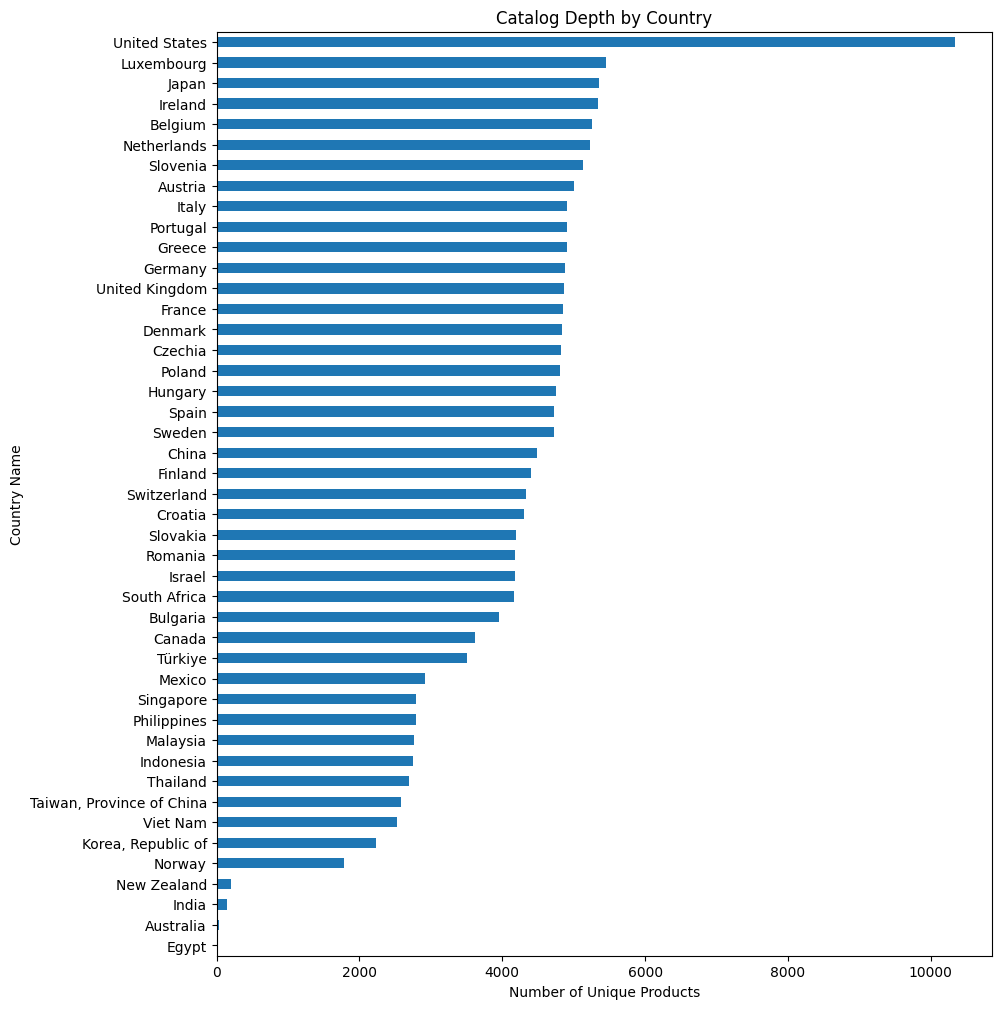

In [5]:
# Starter code: catalog depth by country

records_per_country = pd.DataFrame({
    'total_records': df_nike.groupby('country_name').size(),
    'unique_products': df_nike.groupby('country_name')['product_id'].nunique()
})

records_per_country['difference'] = (
    records_per_country['total_records'] - records_per_country['unique_products']
)

records_per_country['product_share_pct'] = (
    records_per_country['unique_products'] / records_per_country['total_records'] * 100
).round(2)

records_per_country = records_per_country.sort_values('unique_products')

display(records_per_country.head())
display(records_per_country.tail())

ax = records_per_country['unique_products'].plot(kind='barh', figsize=(10, 12))
ax.set_xlabel('Number of Unique Products')
ax.set_ylabel('Country Name')
ax.set_title('Catalog Depth by Country')
plt.show()

# Optional second chart:
# ax = records_per_country['product_share_pct'].plot(kind='barh', figsize=(10, 12))
# ax.set_xlabel('Unique Products as % of Total Rows')
# ax.set_ylabel('Country Name')
# ax.set_title('Unique Product Share by Country')
# plt.show()


## 1.2 Category Distribution Across Markets

**Business question:** Which categories dominate globally and within each country?

**What to examine:**
- Global category distribution using unique products
- Category mix by country
- Most common category in each market
- Balanced vs concentrated category structures
**Interpretation focus:**
- Identify globally dominant categories
- Compare market emphasis across countries
- Notice whether a market looks more **balanced** or more **tilted toward one category**

,global_category_count,category_share_pct
category,,
PHYSICAL_GIFT_CARD,1,0.00
DIGITAL_GIFT_CARD,2,0.01
EQUIPMENT,1830,6.16
FOOTWEAR,7355,24.75
APPAREL,20530,69.08


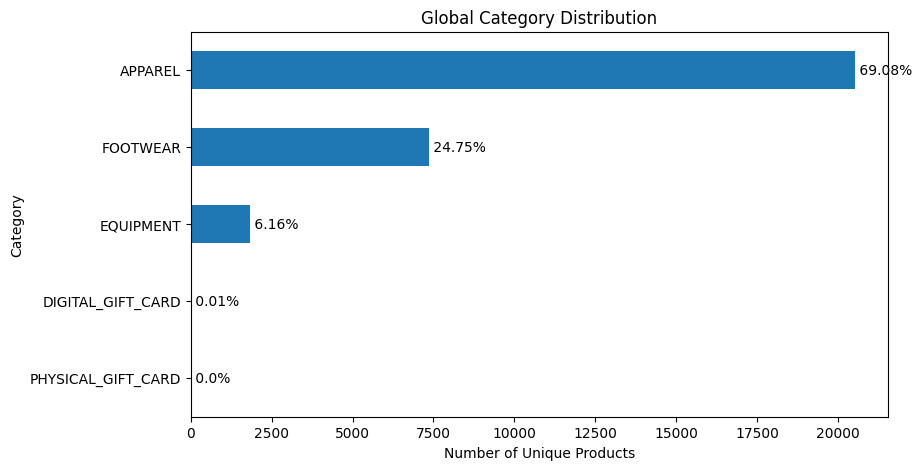

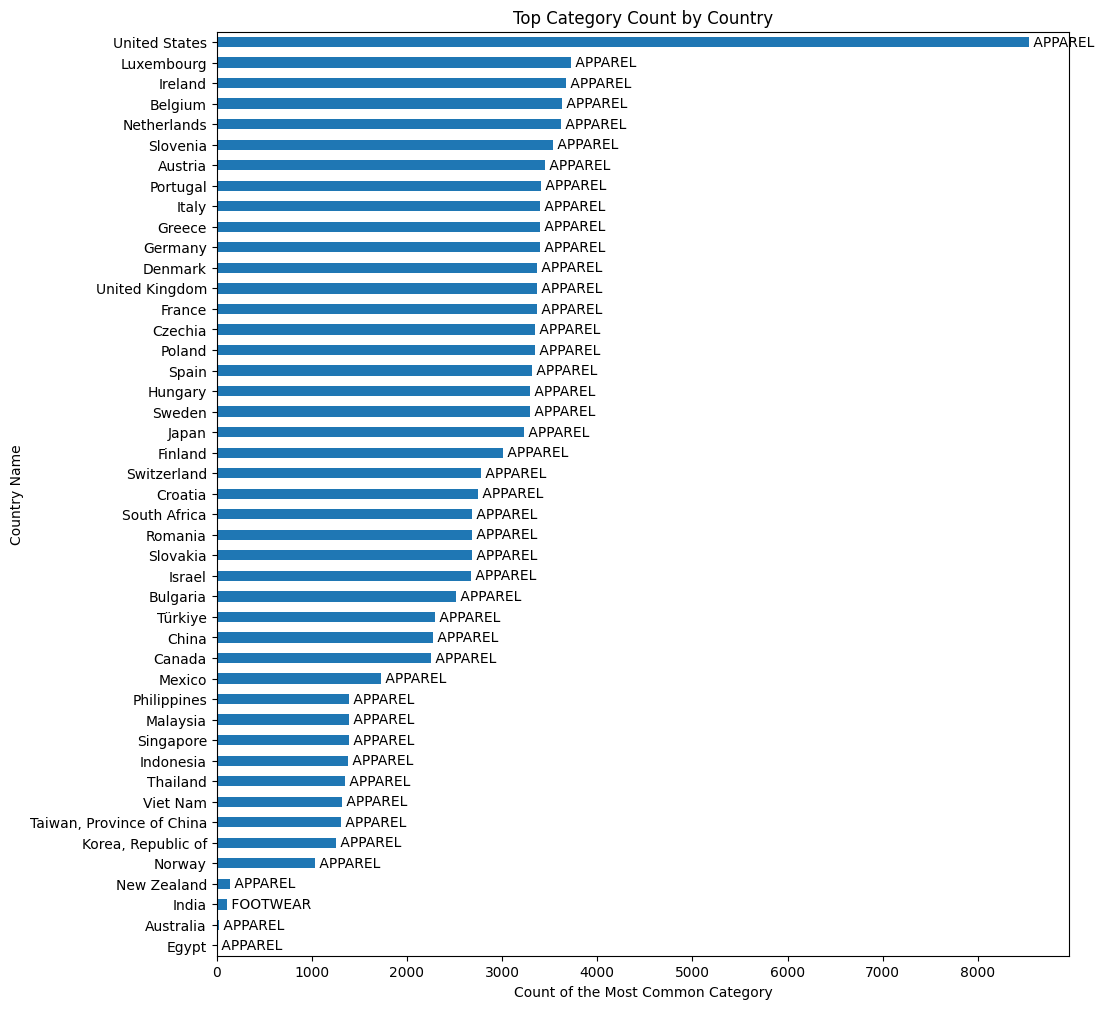

In [6]:
# Starter code: category distribution

category_counts = df_nike.groupby('category')['product_id'].nunique()

category_dist_global = pd.DataFrame({
    'global_category_count': category_counts,
    'category_share_pct': (category_counts / category_counts.sum() * 100).round(2)
}).sort_values('global_category_count')

display(category_dist_global)

ax_cat = category_dist_global['global_category_count'].plot(kind='barh', figsize=(9, 5))
ax_cat.set_xlabel('Number of Unique Products')
ax_cat.set_ylabel('Category')
ax_cat.set_title('Global Category Distribution')

for i, value in enumerate(category_dist_global['global_category_count']):
    ax_cat.text(value, i, f" {category_dist_global['category_share_pct'].iloc[i]}%", va='center')

plt.show()

category_count_per_country = (
    df_nike.groupby(['country_name', 'category'])['product_id']
    .nunique()
    .unstack(fill_value=0)
)

category_count_per_country['most_common_category_count'] = category_count_per_country.max(axis=1)
category_count_per_country['most_common_category'] = category_count_per_country.idxmax(axis=1)

plot_df = category_count_per_country.sort_values('most_common_category_count')

ax = plot_df['most_common_category_count'].plot(kind='barh', figsize=(11, 12))
ax.set_xlabel('Count of the Most Common Category')
ax.set_ylabel('Country Name')
ax.set_title('Top Category Count by Country')

for i, value in enumerate(plot_df['most_common_category_count']):
    ax.text(value, i, f" {plot_df['most_common_category'].iloc[i]}", va='center')

plt.show()

# Optional: stacked country-category view
# category_plot = category_count_per_country.drop(columns=['most_common_category_count', 'most_common_category'])
# ax = category_plot.plot(kind='barh', stacked=True, figsize=(12, 14))
# ax.set_xlabel('Number of Unique Products')
# ax.set_ylabel('Country Name')
# ax.set_title('Category Mix by Country')
# plt.legend(title='Category', bbox_to_anchor=(1.05, 1))
# plt.show()


## 1.3 Subcategory Assortment Patterns

**Business question:** How detailed is the assortment structure within countries?

**Note**
Subcategory labels may be **localized across languages and markets**.  
That means global comparison is informative but not perfectly clean, because similar meanings
may appear under different language labels.

**Interpretation focus:**
- Detect finer specialization patterns
- Show which markets have deeper subcategory variety
- Treat global subcategory rankings with caution if labels are localized


In [74]:
import warnings
warnings.filterwarnings("ignore", message="Glyph .* missing from font")

subcategory
Women's Shoes           586
Men's Shoes             565
メンズシューズ                 445
ウィメンズシューズ               365
Chaussure pour homme    245
Herenschoenen           226
รองเท้าผู้ชาย           224
男鞋                      222
Older Kids' Shoes       221
Chaussure pour femme    211
Name: product_id, dtype: int64

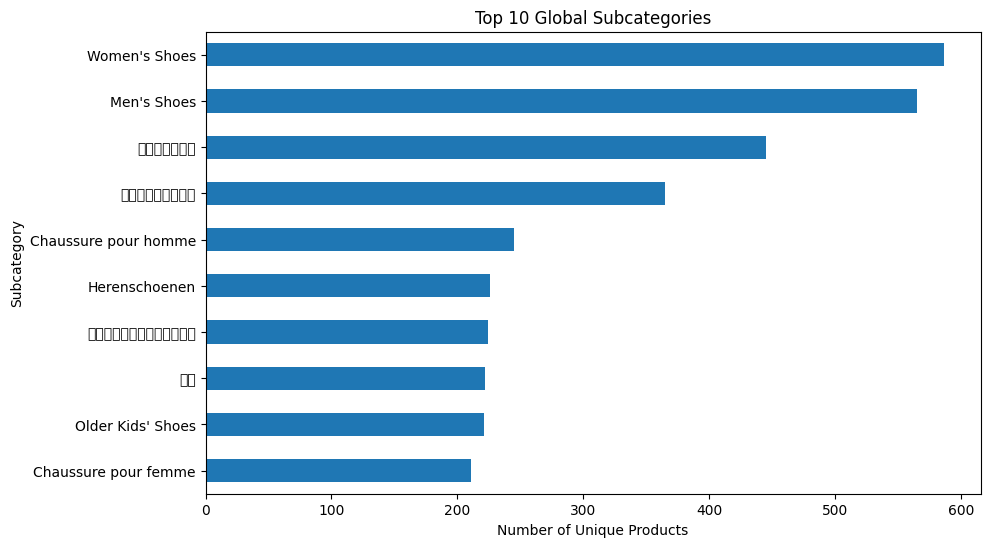

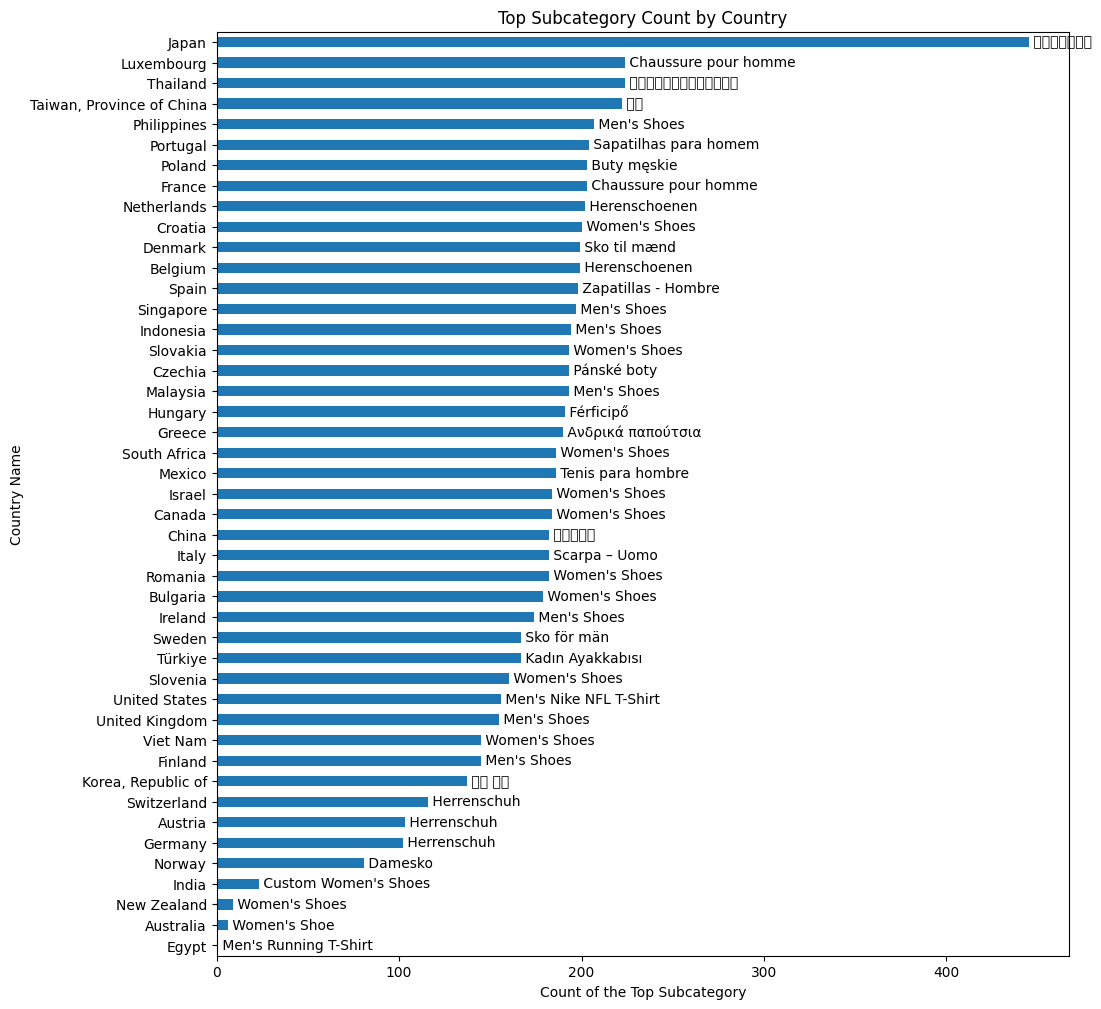

In [75]:
# Starter code: subcategory analysis

sub_cat_global = df_nike.groupby('subcategory')['product_id'].nunique()

top10_sub_cat_global = sub_cat_global.sort_values(ascending=False).head(10)
display(top10_sub_cat_global)

ax = top10_sub_cat_global.sort_values().plot(kind='barh', figsize=(10, 6))
ax.set_xlabel('Number of Unique Products')
ax.set_ylabel('Subcategory')
ax.set_title('Top 10 Global Subcategories')
plt.show()

sub_cat_per_country = (
    df_nike.groupby(['country_name', 'subcategory'])['product_id']
    .nunique()
    .unstack(fill_value=0)
)

sub_cat_per_country['top_subcategory_count'] = sub_cat_per_country.max(axis=1)
sub_cat_per_country['top_subcategory'] = sub_cat_per_country.idxmax(axis=1)

plot_df = sub_cat_per_country.sort_values('top_subcategory_count')

ax = plot_df['top_subcategory_count'].plot(kind='barh', figsize=(11, 12))
ax.set_xlabel('Count of the Top Subcategory')
ax.set_ylabel('Country Name')
ax.set_title('Top Subcategory Count by Country')

for i, value in enumerate(plot_df['top_subcategory_count']):
    ax.text(value, i, f" {plot_df['top_subcategory'].iloc[i]}", va='center')

plt.show()

# Optional data quality check:
# df_nike['subcategory'].dropna().sample(20)


## 1.4 Gender Segment Mix by Country

**Business question:** How does Nike target customer segments across markets?

**Note**
gender_segment is missing for Egypt

**Interpretation focus:**
- Highlight dominant customer segments by market
- Compare more balanced vs more focused gender mixes

gender_segment
MEN|BOYS|GIRLS              1
MEN|WOMEN|GIRLS             2
WOMEN|GIRLS                 4
BOYS|WOMEN|GIRLS           11
MEN|BOYS|WOMEN|GIRLS      106
GIRLS                     946
BOYS                     1376
BOYS|GIRLS               3394
MEN|WOMEN                3795
WOMEN                    7419
MEN                     12849
Name: product_id, dtype: int64

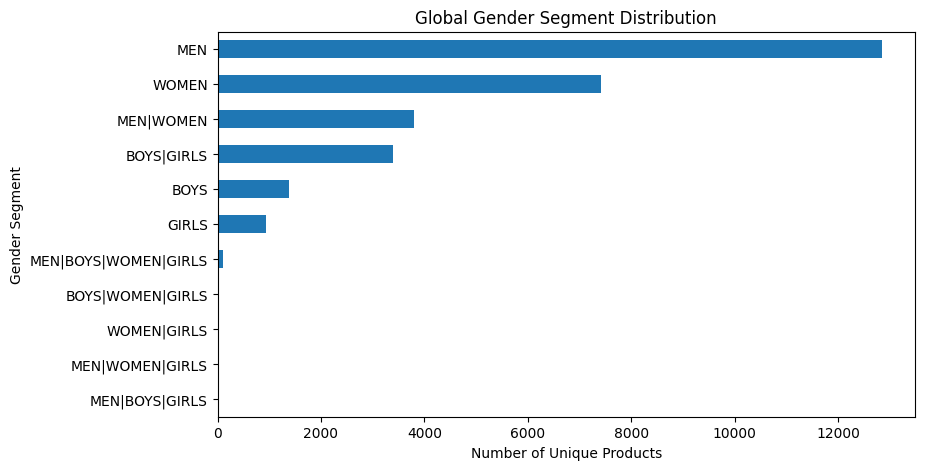

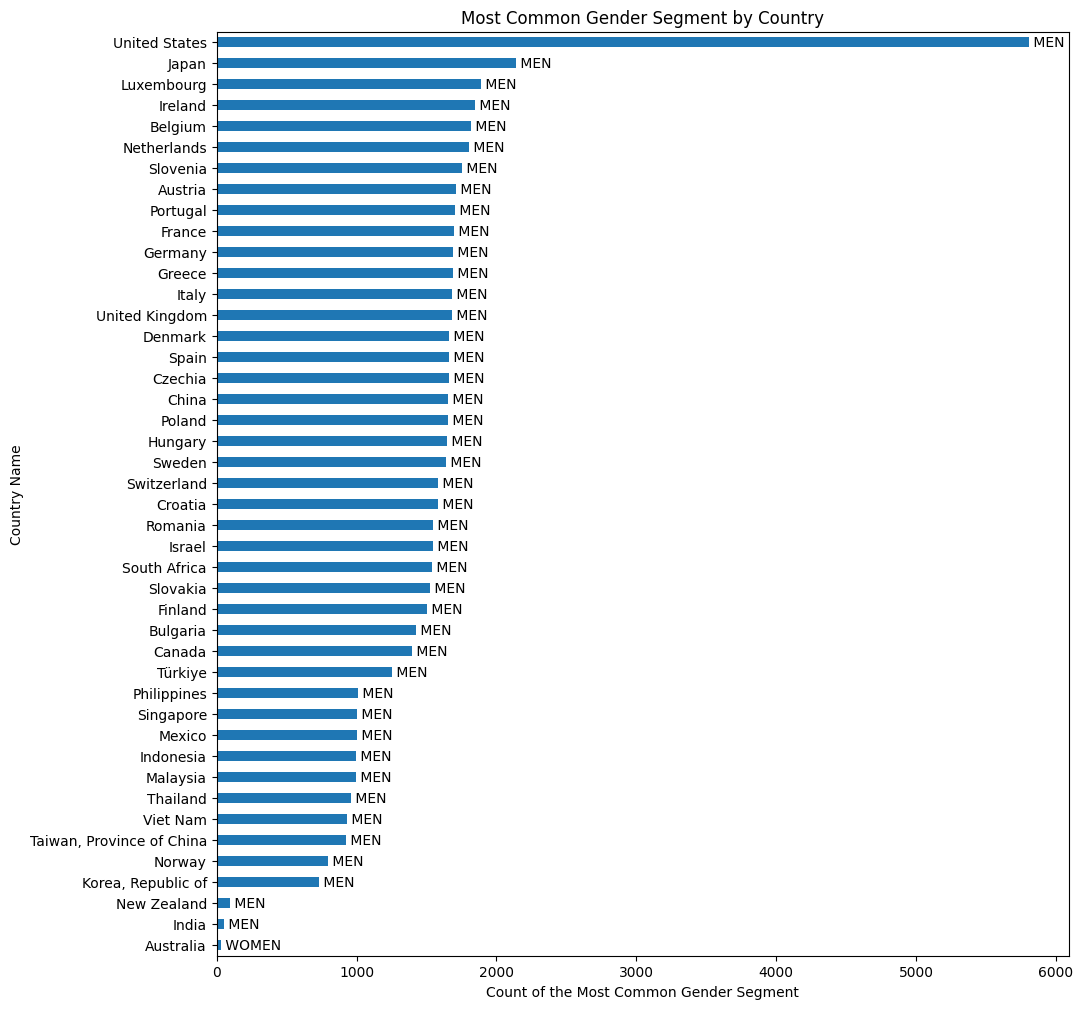

In [8]:
# Starter code: gender-segment analysis

gender_global = (
    df_nike.groupby('gender_segment')['product_id']
    .nunique()
    .sort_values()
)

display(gender_global)

ax = gender_global.plot(kind='barh', figsize=(9, 5))
ax.set_xlabel('Number of Unique Products')
ax.set_ylabel('Gender Segment')
ax.set_title('Global Gender Segment Distribution')
plt.show()

gender_dist_per_country = (
    df_nike.groupby(['country_name', 'gender_segment'])['product_id']
    .nunique()
    .unstack(fill_value=0)
)

gender_dist_per_country['most_common_gender_count'] = gender_dist_per_country.max(axis=1)
gender_dist_per_country['most_common_gender'] = gender_dist_per_country.idxmax(axis=1)

plot_df = gender_dist_per_country.sort_values('most_common_gender_count')

ax = plot_df['most_common_gender_count'].plot(kind='barh', figsize=(11, 12))
ax.set_xlabel('Count of the Most Common Gender Segment')
ax.set_ylabel('Country Name')
ax.set_title('Most Common Gender Segment by Country')

for i, value in enumerate(plot_df['most_common_gender_count']):
    ax.text(value, i, f" {plot_df['most_common_gender'].iloc[i]}", va='center')

plt.show()

# Optional: stacked country-gender view
# gender_plot = gender_dist_per_country.drop(columns=['most_common_gender_count', 'most_common_gender'])
# ax = gender_plot.plot(kind='barh', stacked=True, figsize=(12, 14))
# ax.set_xlabel('Number of Unique Products')
# ax.set_ylabel('Country Name')
# ax.set_title('Gender Segment Mix by Country')
# plt.legend(title='Gender Segment', bbox_to_anchor=(1.05, 1))
# plt.show()


### Section 1 Final Observations

- The broadest assortments are concentrated in large markets such as the **United States** and several major European markets including **Luxembourg, Ireland, Belgium, the Netherlands, Germany, Italy, Greece, Portugal, France, and Austria**, all of which show high counts of unique products. In contrast, markets such as **Egypt, Australia, India, and New Zealand** appear much narrower.

- At the **global category** level, **APPAREL** is the dominant category, followed by **FOOTWEAR**, while **EQUIPMENT** is much smaller and gift-card categories are negligible in most markets. At the **country** level, APPAREL is the leading category in most markets, although the relative importance of FOOTWEAR becomes stronger in some Asian and smaller catalogs.

- Subcategory analysis gives a more detailed view of assortment structure, but the results are clearly affected by **localized naming conventions**. The same commercial meaning may appear in different languages across countries, which weakens direct global comparison of subcategory labels. Therefore, subcategory results are more reliable for assessing **within-country assortment depth** than for strict cross-country ranking of specific subcategory names.

- Gender-segment analysis helps identify which customer segments dominate each market. In the major markets, assortment appears concentrated mainly in a limited set of large segments rather than being evenly distributed across all possible gender labels. However, these findings should be interpreted carefully in markets where `gender_segment` had missing values during cleaning, especially structurally incomplete cases such as **Egypt**.



---
# Section 2: Price Intelligence

## Goal
Analyze pricing, discounts, and promotional behavior across countries and categories.


## 2.1 Price Levels by Country

**Business question:** Which countries have the highest and lowest prices?

- Average regular price by country
- Average sale price by country
- Markets with higher pricing levels


In [9]:
df_nike['currency'].nunique()
snapshot_date = df_nike['snapshot_date'].max()

In [10]:
import requests
currencies = sorted(df_nike['currency'].dropna().unique().tolist())
quotes = ",".join([c for c in currencies if c != 'EUR'])
url = f"https://api.frankfurter.dev/v2/rates?date={snapshot_date}&base=EUR&quotes={quotes}"
response = requests.get(url) 
data = response.json()
rate_table = pd.DataFrame(data)
rate_table = pd.DataFrame(data)[['quote', 'rate']].rename(columns={'quote': 'currency'})

rate_table['rate_to_eur'] = 1 / rate_table['rate']

rate_table = pd.concat([
    pd.DataFrame({'currency': ['EUR'], 'rate_to_eur': [1.0]}),
    rate_table[['currency', 'rate_to_eur']]
], ignore_index=True)
df_nike = df_nike.merge(rate_table, on='currency', how='left')
df_nike['price_eur'] = df_nike['price_local'] * df_nike['rate_to_eur']
df_nike['sale_price_eur'] = df_nike['sale_price_local'] * df_nike['rate_to_eur']

In [11]:
keys = ['product_name', 'category', 'product_id', 'gender_segment', 'size_label']

median_ref = (
    df_nike.loc[df_nike['country_name'] != 'New Zealand']
    .groupby(keys)['price_eur']
    .median()
    .reset_index()
    .rename(columns={'price_eur': 'median_price_eur'})
)
mask_bad_nz = (
    (df_nike['country_name'] == 'New Zealand') &
    (df_nike['price_local'] == 100000)
)
nz_bad = df_nike.loc[mask_bad_nz].merge(
    median_ref,
    on=keys,
    how='left'
)
df_nike.loc[mask_bad_nz, 'price_eur'] = nz_bad['median_price_eur'].values

df_nike.loc[mask_bad_nz, 'price_local'] = (
    df_nike.loc[mask_bad_nz, 'price_eur'] / df_nike.loc[mask_bad_nz, 'rate_to_eur']
).round(2)

In [12]:
product_price_per_country = (
    df_nike.loc[df_nike['price_eur'] > 0]
    .groupby(['country_name', 'product_id'])['price_eur']
    .first()
    .reset_index()
)

In [13]:
avg_price_per_country = round(product_price_per_country.groupby('country_name')['price_eur'].mean().sort_values(),2)

In [14]:
#df_nike.loc[df_nike["country_name"] == "New Zealand",["price_local","country_name",'price_eur']].value_counts()

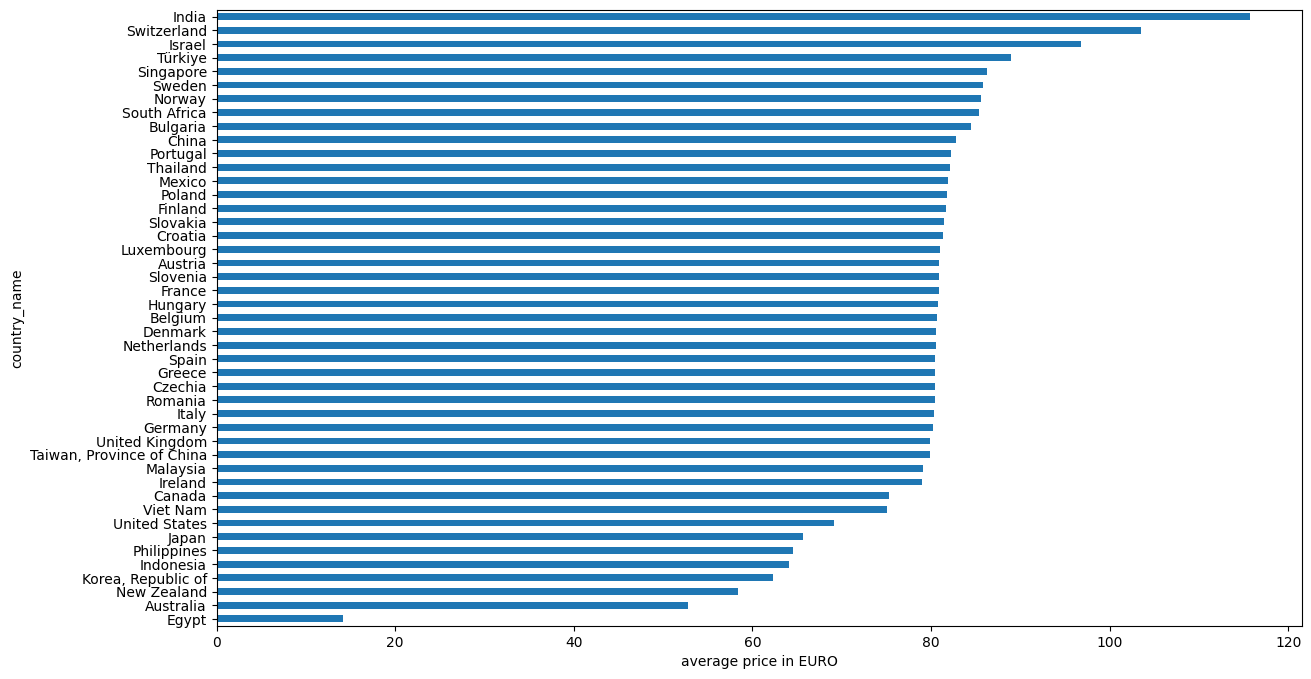

In [15]:
ax_avg_price_per_country = avg_price_per_country.plot(kind = 'barh',figsize=(14,8))
ax_avg_price_per_country.set_xlabel('average price in EURO')
ax_avg_price_per_country.set_ylabel('country_name')
plt.show()

In [16]:
highest_price_per_country = round(product_price_per_country.groupby('country_name')['price_eur'].max().sort_values(),2)

In [17]:
highest_price_per_country

country_name
Egypt                         14.12
Australia                     98.72
New Zealand                  238.18
India                        253.53
Viet Nam                     303.64
Mexico                       356.01
Canada                       373.77
Taiwan, Province of China    453.04
Norway                       458.55
Romania                      491.03
Croatia                      499.99
Bulgaria                     499.99
Slovakia                     499.99
China                        504.78
Türkiye                      549.55
Indonesia                    554.16
Philippines                  566.72
Korea, Republic of           568.83
Israel                       579.99
Spain                        599.99
Hungary                      599.99
Switzerland                  626.61
South Africa                 637.82
Japan                        691.75
Singapore                    698.76
Thailand                     717.78
Malaysia                     728.89
Denmark        

In [18]:
lowest_price_per_counrty = round(product_price_per_country.groupby('country_name')['price_eur'].min().sort_values(),2)

In [19]:
lowest_price_per_counrty

country_name
Türkiye                       4.32
Philippines                   5.01
Korea, Republic of            5.29
Indonesia                     5.59
China                         6.19
Taiwan, Province of China     6.56
Viet Nam                      6.58
United States                 6.93
Japan                         7.22
United Kingdom                7.51
Canada                        7.60
Malaysia                      7.74
Thailand                      7.98
Singapore                     8.15
Italy                         8.49
Austria                       8.49
Netherlands                   8.49
Luxembourg                    8.49
Ireland                       8.49
Belgium                       8.49
Czechia                       8.49
Germany                       8.49
Hungary                       8.49
Slovenia                      8.49
Spain                         8.49
Greece                        8.49
Denmark                       9.36
Finland                       9.49
Mexico 

## 2.2 Price Patterns by Category

**Business question:** How do prices vary across product categories?

**What to examine:**
- Average price by category
- Price spread within categories
- Premium vs lower-priced categories


In [20]:
price_per_category = (
    df_nike.loc[df_nike['price_eur'] > 0]
    .groupby(['category', 'product_id'])['price_eur']
    .first()
    .reset_index()
)

In [21]:
avg_price_per_category = round(price_per_category.groupby('category')['price_eur'].mean().sort_values(),2)

In [22]:
avg_price_per_category

category
EQUIPMENT     46.63
APPAREL       63.53
FOOTWEAR     102.82
Name: price_eur, dtype: float64

In [23]:
category_summary = (
    price_per_category.groupby('category')['price_eur']
    .agg(['min', 'median', 'max', 'mean', 'std'])
    .round(2)
)

In [24]:
category_summary

,min,median,max,mean,std
category,,,,,
APPAREL,6.19,52.17,749.99,63.53,43.76
EQUIPMENT,6.15,29.88,955.57,46.63,56.00
FOOTWEAR,17.44,93.24,873.84,102.82,51.47


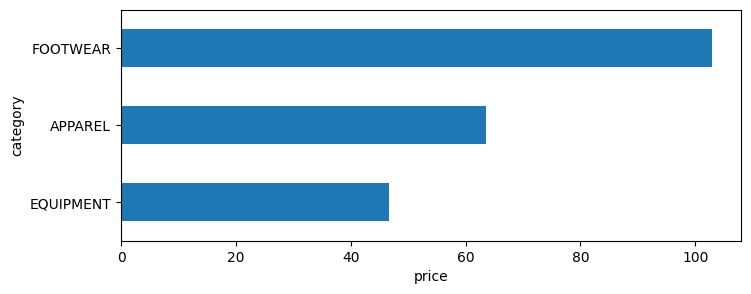

In [25]:
ax_avg_pric_per_cat = avg_price_per_category.plot(kind = "barh",figsize=(8,3))
ax_avg_pric_per_cat.set_xlabel('price')
ax_avg_pric_per_cat.set_ylabel('category')
plt.show()

## 2.3 Discount Intensity Across Markets

**Business question:** Which countries rely more heavily on promotions?

**What to examine:**
- Share of discounted products by market



In [26]:
discount_coverage = (
    df_nike.groupby('country_name')['sale_price_local']
    .apply(lambda x: x.notna().mean())
)

valid_discount_markets = discount_coverage[discount_coverage >= 0.2].index.tolist()

disc_country = df_nike[
    df_nike['country_name'].isin(valid_discount_markets) &
    df_nike['sale_price_eur'].notna()
]
disc_product_per_country=disc_country.groupby('country_name')['product_id'].nunique()
total_product_per_country = df_nike[df_nike['country_name'].isin(valid_discount_markets)].groupby('country_name')['product_id'].nunique()
share_of_disc_per_country = round((disc_product_per_country/total_product_per_country)*100 ,2).sort_values()

In [27]:
share_of_disc_per_country

country_name
Australia                    13.89
Israel                       20.43
United States                22.11
Singapore                    26.78
Philippines                  27.24
Indonesia                    27.39
Thailand                     27.42
Malaysia                     27.47
Taiwan, Province of China    27.51
Viet Nam                     28.03
Korea, Republic of           33.12
Japan                        39.43
China                        43.42
Mexico                       46.18
Name: product_id, dtype: float64

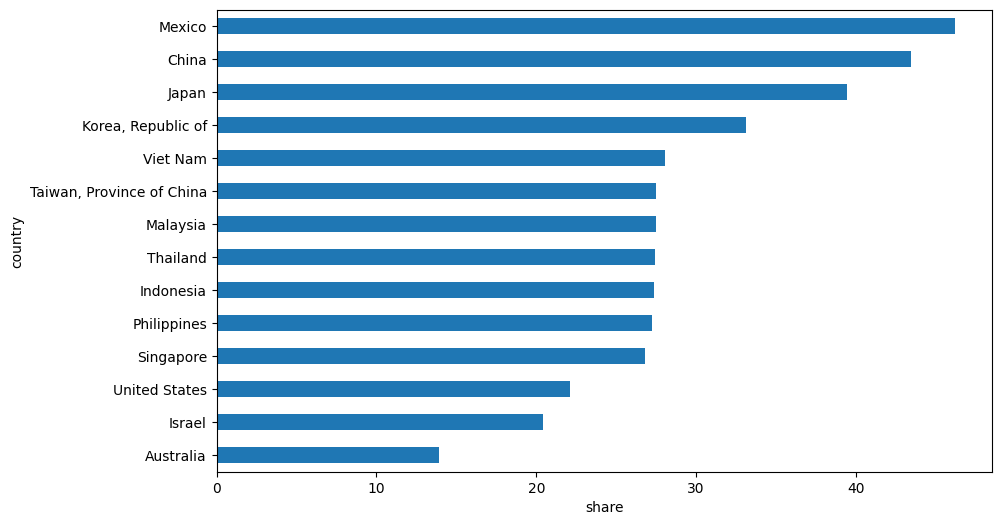

In [28]:
ax_share_of_disc_per_country = share_of_disc_per_country.plot(kind = 'barh',figsize=(10,6))
ax_share_of_disc_per_country.set_xlabel('share')
ax_share_of_disc_per_country.set_ylabel('country')
plt.show()

## 2.4 Discount Patterns by Category and Segment

**Business question:** Are discounts concentrated in certain product groups?

**What to examine:**
- Discount by category
- Discount by gender segment
- Categories with stronger markdown behavior


In [29]:
disc_product_per_category=disc_country.groupby('category')['product_id'].nunique()
total_product_per_category = df_nike.groupby('category')['product_id'].nunique()
share_of_disc_per_category = round(   (
    disc_product_per_category / total_product_per_category
).fillna(0).sort_values(ascending=False),2)

share_of_disc_per_category

category
FOOTWEAR              0.37
APPAREL               0.29
EQUIPMENT             0.24
DIGITAL_GIFT_CARD     0.00
PHYSICAL_GIFT_CARD    0.00
Name: product_id, dtype: float64

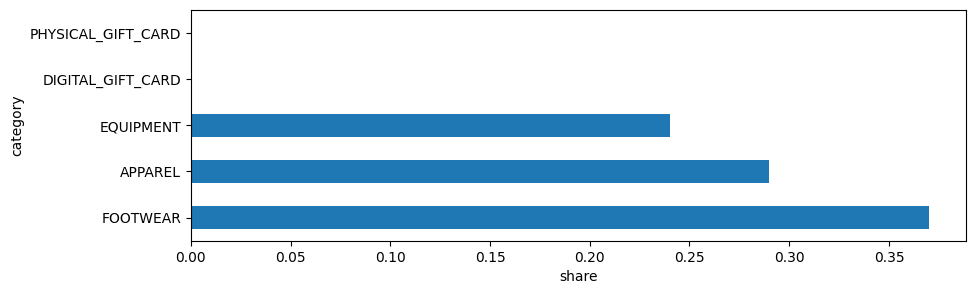

In [30]:
ax_share_of_disc_per_category = share_of_disc_per_category.plot(kind = 'barh',figsize = (10,3))
ax_share_of_disc_per_category.set_xlabel('share')
ax_share_of_disc_per_category.set_ylabel('category')
plt.show()

In [31]:
disc_product_per_gender=disc_country.groupby('gender_segment')['product_id'].nunique()
total_product_per_gender = df_nike.groupby('gender_segment')['product_id'].nunique()
share_of_disc_per_gender = round(   (
    disc_product_per_gender / total_product_per_gender
).sort_values(ascending=False),2)

share_of_disc_per_gender

gender_segment
BOYS|WOMEN|GIRLS        0.45
WOMEN                   0.35
BOYS|GIRLS              0.34
GIRLS                   0.32
MEN|WOMEN               0.30
MEN                     0.27
BOYS                    0.25
MEN|BOYS|WOMEN|GIRLS    0.13
MEN|BOYS|GIRLS           NaN
MEN|WOMEN|GIRLS          NaN
WOMEN|GIRLS              NaN
Name: product_id, dtype: float64

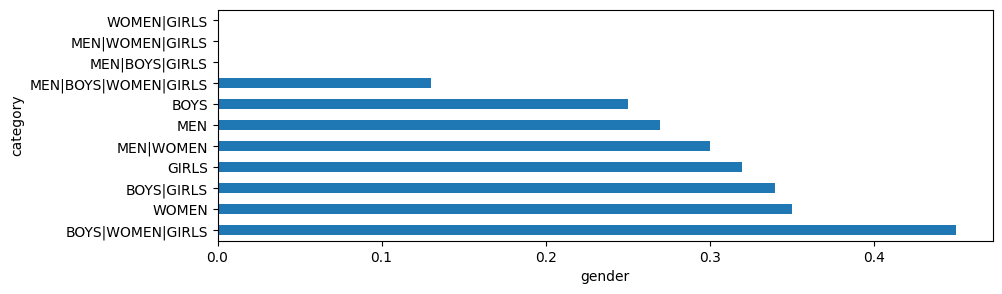

In [32]:
ax_disc_product_per_gender = share_of_disc_per_gender.plot(kind = 'barh',figsize = (10,3))
ax_disc_product_per_gender.set_xlabel('gender')
ax_disc_product_per_gender.set_ylabel('category')
plt.show()

## 2.5 Price Dispersion for Shared Products

**Business question:** How differently are similar or matched products priced across countries?

**What to examine:**
- Same product across multiple markets
- Cross-country regular price differences
- Cross-country sale price differences


In [33]:
shared_products = df_nike.groupby('product_id')['country_name'].nunique()
shared_products = shared_products[shared_products >=2].index

In [34]:
df_shared = df_nike.loc[df_nike['product_id'].isin(shared_products),['country_name','product_id','nike_size','price_eur','sale_price_eur']]

In [35]:
product_across_markets_pice = df_shared.pivot_table(
                                    index =['product_id','nike_size'],
                                    columns ='country_name',
                                    values = 'price_eur',
                                    aggfunc = 'mean'
)

In [36]:
df_shared_sale = df_nike.loc[df_nike['product_id'].isin(shared_products) & df_nike['sale_price_eur'].notna(),
                                       ['country_name','product_id','nike_size','price_eur','sale_price_eur']]

In [37]:
product_across_markets_sale_price =df_shared_sale.pivot_table(
                                    index =['product_id','nike_size'],
                                    columns ='country_name',
                                    values = 'sale_price_eur',
                                    aggfunc = 'mean')

## Section 2 Summary

- Country-level pricing shows that Nike’s catalog is **not priced uniformly across markets**. Average, minimum, and maximum observed prices differ across countries, indicating a localized pricing structure rather than one fully standardized global price level.

- At the category level, **FOOTWEAR** has the highest average price, followed by **APPAREL**, while **EQUIPMENT** has the lowest average price. This positions footwear as the most premium category in the catalog.

- Discount activity varies across countries. After limiting the analysis to markets with meaningful sale-price coverage, the discounted-product share differs clearly by country, which suggests that promotion intensity is not applied equally across markets.

- Discount patterns also differ by product group. In the current calculations, **FOOTWEAR** has the highest discounted-product share, followed by **APPAREL**, while **EQUIPMENT** shows the lowest markdown intensity.

- By gender segment, markdown activity is also uneven, but these results should be interpreted carefully because some gender groups are sparse and some ratios contain missing values.

- A **sale price rate over time** was not analyzed here and cannot be measured from this dataset alone, because the dataset is a **single snapshot**. It contains prices observed at the snapshot date, but it does not include the product price **before the markdown period** or prices from earlier dates.

- The shared-product analysis is limited because only a relatively small number of product and size combinations are available across multiple markets. As a result, the comparison matrix is sparse, with many missing values, which makes broad cross-country comparison more difficult and reduces the strength of conclusions drawn from shared items alone.


---
# Section 3: Size Availability Modeling

## Goal
Analyze stock exposure and size coverage across countries, categories, and product lines.


## 3.1 In-Stock Rate by Country

**Business question:** Which markets show stronger product availability?

**What to examine:**
- Product-level availability by country
- Size-level in-stock rate by country
- Countries with stronger and weaker availability


In [38]:
df_nike[['availability_level','available_market','in_stock','available']].value_counts()

availability_level  available_market  in_stock  available
LOW                 True              True      True         496767
HIGH                True              True      True         493247
OOS                 True              True      False        354456
MEDIUM              True              True      True          87663
OOS                 False             False     False         15660
Name: count, dtype: int64

In [39]:
availablility_across_country = round((df_nike[df_nike['in_stock']].groupby('country_name')['product_id'].nunique()
                                     / df_nike.groupby('country_name')['product_id'].nunique()).sort_values(),2)

In [40]:
availablility_across_country_rate=df_nike.groupby('country_name')['in_stock'].mean().round(2).sort_values()

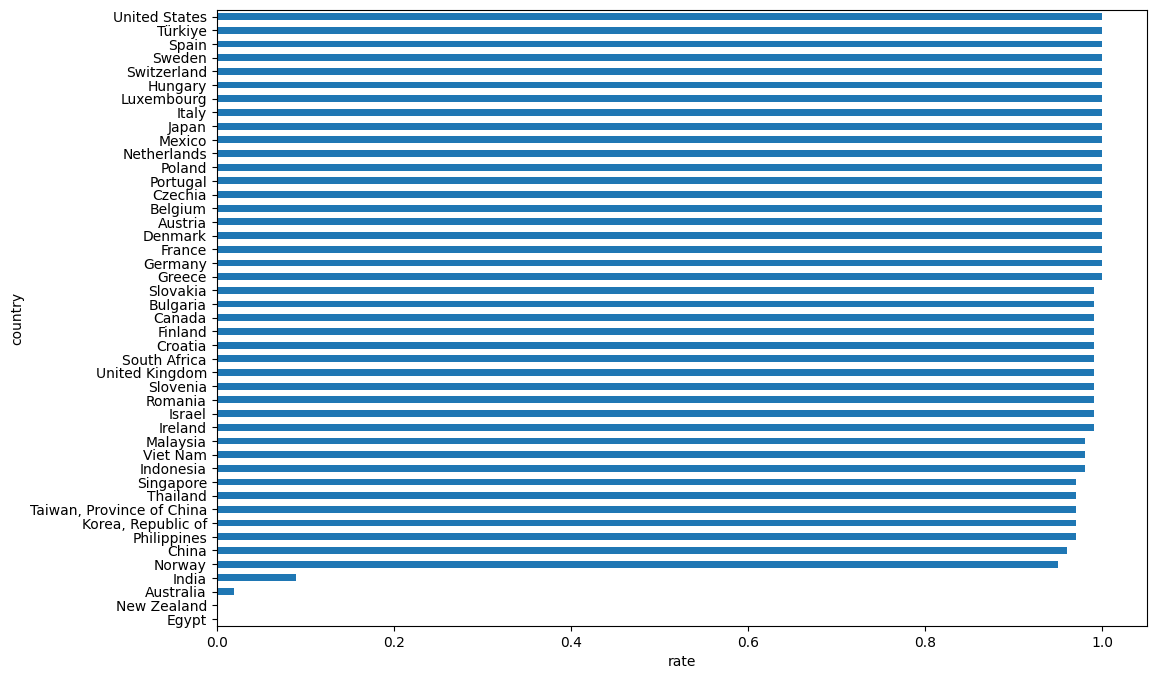

In [41]:
ax_availablility_across_country_rate = availablility_across_country_rate.plot(kind = 'barh',figsize=(12,8))
ax_availablility_across_country_rate.set_xlabel('rate')
ax_availablility_across_country_rate.set_ylabel('country')
plt.show()

In [42]:
availablility_across_country_rate

country_name
Egypt                        0.00
New Zealand                  0.00
Australia                    0.02
India                        0.09
Norway                       0.95
China                        0.96
Philippines                  0.97
Korea, Republic of           0.97
Taiwan, Province of China    0.97
Thailand                     0.97
Singapore                    0.97
Indonesia                    0.98
Viet Nam                     0.98
Malaysia                     0.98
Ireland                      0.99
Israel                       0.99
Romania                      0.99
Slovenia                     0.99
United Kingdom               0.99
South Africa                 0.99
Croatia                      0.99
Finland                      0.99
Canada                       0.99
Bulgaria                     0.99
Slovakia                     0.99
Greece                       1.00
Germany                      1.00
France                       1.00
Denmark                      1.00
A

## 3.2 Availability by Category and Subcategory

**Business question:** Which product groups have weaker stock coverage?

**What to examine:**
- Product-level availability by category
- Size-level in-stock rate by category
- Product-level availability by subcategory
- Weak vs strong product groups


In [43]:
available_product_per_category =round((df_nike[df_nike['in_stock']].groupby('category')['product_id'].nunique()
                                  / df_nike.groupby('category')['product_id'].nunique()),2).sort_values()

In [44]:
available_product_per_category

category
EQUIPMENT             0.97
FOOTWEAR              0.98
APPAREL               0.99
DIGITAL_GIFT_CARD     1.00
PHYSICAL_GIFT_CARD    1.00
Name: product_id, dtype: float64

In [45]:
available_product_per_category_rate = df_nike.groupby('category')['in_stock'].mean().round(2).sort_values()

In [46]:
available_product_per_category_rate

category
EQUIPMENT             0.98
APPAREL               0.99
FOOTWEAR              0.99
DIGITAL_GIFT_CARD     1.00
PHYSICAL_GIFT_CARD    1.00
Name: in_stock, dtype: float64

In [47]:
available_product_per_sub_category =round((df_nike[df_nike['in_stock']].groupby('subcategory')['product_id'].nunique()
                                  / df_nike.groupby('subcategory')['product_id'].nunique()),2).sort_values(ascending = False).dropna()

In [48]:
available_product_per_sub_category

subcategory
헤리티지 웨이스트팩                                            1.00
\r\nSapatilhas de atletismo para sprint               1.00
 Dri-FIT-golfshorts til kvinder                       1.00
 Low-Top-Fußballschuh                                 1.00
 Low-Top-Fußballschuh für jüngere/ältere Kinder       1.00
                                                      ... 
Trenings-T-skjorte til herre                          0.33
남성 프리게임 뮬                                             0.33
莫兰特大童篮球鞋                                              0.25
Maglia da calcio Authentic Nike Dri-FIT ADV – Uomo    0.25
Women's Shoe                                          0.11
Name: product_id, Length: 48178, dtype: float64

## 3.3 Size Coverage by Product

**Business question:** How many sizes are offered and how many are actually available?

**What to examine:**
- Listed sizes vs available sizes
- Size coverage rate
- Size coverage gap
- Products or markets with weak size fulfillment


In [49]:
listed_sizes = (
    df_nike.groupby(['country_name', 'product_id'])['localized_size']
    .nunique()
    .rename('listed_sizes').reset_index()
)

available_sizes = (
    df_nike[df_nike['in_stock']]
    .groupby(['country_name', 'product_id'])['localized_size']
    .nunique()
    .rename('available_sizes')
).reset_index()

In [52]:
size_coverage = listed_sizes.merge(
    available_sizes,
    on=['country_name', 'product_id'],
    how='left'
)

In [53]:
size_coverage['available_sizes'] = size_coverage['available_sizes'].fillna(0).astype(int)

In [54]:
size_coverage ['size_coverage_rate'] = size_coverage['available_sizes'] / size_coverage['listed_sizes']
size_coverage['size_gap'] = size_coverage['listed_sizes'] - size_coverage['available_sizes']

In [70]:
size_coverage

,country_name,product_id,listed_sizes,available_sizes,size_coverage_rate,size_gap
0,Australia,07bbf685-873c-3294-b6bc-8d3b29bcd3fb,11,0,0.0,11
1,Australia,1a0beae3-17b2-3a83-9b2b-6864cfecfe17,5,0,0.0,5
2,Australia,2a20403f-0fc1-456f-8934-050fc78333ab,0,0,NaN,0
3,Australia,30b4eaf0-b972-3e6f-ad65-b2fd2028f0dd,3,0,0.0,3
4,Australia,3395eea9-c36e-3995-b07f-289523b33204,5,0,0.0,5
...,...,...,...,...,...,...
176653,Viet Nam,ffd0412e-e4d2-4a0d-bbb8-1d54268957dc,5,5,1.0,0
176654,Viet Nam,ffd6fc28-9d11-45d4-beb0-d26ca320f05d,5,5,1.0,0
176655,Viet Nam,ffe24390-6189-4459-81be-8dfa80af155b,4,4,1.0,0
176656,Viet Nam,ffece15f-145c-4a2e-8ced-002874887fa8,15,15,1.0,0


In [50]:
idx = listed_sizes.groupby('country_name')['listed_sizes'].idxmax()
top_products = listed_sizes.loc[idx].sort_values('listed_sizes')

top_products

,country_name,product_id,listed_sizes
36347,Egypt,ee251e5d-2221-3d42-9368-a865885e2c65,0
101402,New Zealand,00cc60b9-81af-3058-8982-1bd3d2733724,0
9,Australia,3f1ef020-144a-3e3b-8ee4-927f083f78a8,15
60248,India,ceadf670-ef28-4303-b84a-4b066198a37a,20
95051,Mexico,9e51c049-d39c-4edf-b625-90d141fa9a5f,22
18183,China,12ea5f34-f501-4388-b827-2b519cb0a4a0,26
77624,Japan,081688bf-fec5-41ea-a7ce-b9eef1977548,27
83771,"Korea, Republic of",73ac2921-72d9-428c-a0fe-34d9b071d31c,27
91539,Malaysia,6455f337-3d24-427a-8c3e-67a60826c45f,29
61312,Indonesia,6455f337-3d24-427a-8c3e-67a60826c45f,29


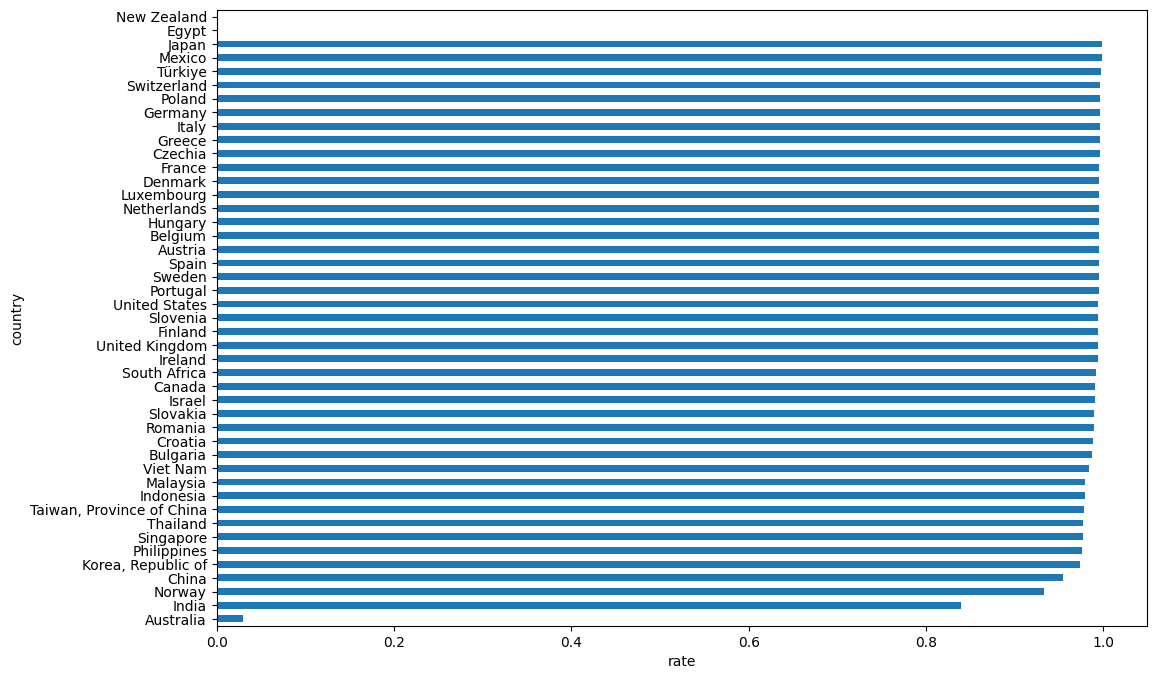

In [73]:
avg_size_coverage_by_country = (
    size_coverage.groupby('country_name')['size_coverage_rate']
    .mean()
    .sort_values()
)

ax_size_coverage = avg_size_coverage_by_country.plot(
    kind='barh',
    figsize=(12,8)
)
ax_size_coverage.set_xlabel('rate')
ax_size_coverage.set_ylabel('country')
plt.show()

In [56]:
availabe_products_per_gender_rate = df_nike.groupby('gender_segment')['in_stock'].mean().round(2).sort_values()

In [57]:
availabe_products_per_gender_rate

gender_segment
WOMEN|GIRLS             0.88
BOYS                    0.99
GIRLS                   0.99
BOYS|GIRLS              0.99
MEN|WOMEN               0.99
MEN|BOYS|WOMEN|GIRLS    0.99
WOMEN                   0.99
MEN                     0.99
MEN|BOYS|GIRLS          1.00
BOYS|WOMEN|GIRLS        1.00
MEN|WOMEN|GIRLS         1.00
Name: in_stock, dtype: float64

## Section 3 Summary

- Availability is **not uniform across markets**. Country-level results show meaningful differences in both **product-level availability** and **size-level in-stock rates**, which suggests that broad catalog presence does not always translate into equally strong stock depth.

- Category-level patterns are easier to interpret and show that some product groups are **more consistently available** than others, both in terms of product presence and observed in-stock rates.

- Subcategory-level results should be interpreted more carefully. They are **harder to explain** because subcategory names appear to vary across markets and may reflect **localized naming** rather than a fully standardized global structure.

- Size coverage provides a **more precise measure of stock depth** than simple product availability, because a product can be counted as available even when only part of its listed size range is actually in stock.

- The gap between **listed sizes** and **available sizes** helps identify products and markets where catalog breadth looks strong, but actual fulfillment depth is weaker.



---
# Final Summary

- Nike's global catalog is **not fully standardized across markets**. Assortment breadth, pricing, and availability all show clear cross-country variation.

- Larger markets often offer **broader assortments**, but stronger catalog breadth does not always translate into equally strong **stock depth**.

- Pricing patterns are also **market-specific**, with meaningful differences across countries and with **FOOTWEAR** generally positioned as the most premium category.

- Overall, the results suggest a mix of **global product structure** and **local market adaptation**, especially in assortment composition, price positioning, and size availability.
